# Email Spam Detection with Machine Learning

**Oasis Infobyte Data Science Internship — Task 4**

**Objective:** Build a Natural Language Processing (NLP) binary classification model that distinguishes spam messages from legitimate (ham) messages.

# Steps Included

1. Import Required Libraries
2. Load the Dataset
3. Understand the Dataset
4. Rename and Organize Dataset Columns
5. Check Data Types and Dataset Shape
6. Check for Missing Values
7. Check for Duplicate Messages
8. Analyze Class Distribution
9. Visualize Spam vs Ham Distribution
10. Text Preprocessing
11. Convert Text to Lowercase
12. Remove Punctuation and Unwanted Characters
13. Remove Stopwords
14. Optional Stemming/Lemmatization
15. Understand TF-IDF
16. Convert Text into TF-IDF Features
17. Prepare Features and Target
18. Split the Dataset into Training and Testing Sets
19. Train Multinomial Naive Bayes Model
20. Train Logistic Regression Model
21. Make Predictions
22. Evaluate Naive Bayes Model
23. Evaluate Logistic Regression Model
24. Generate Confusion Matrices
25. Compare Classification Models
26. Explain the Importance of Recall for Spam Detection
27. WordCloud Visualization for Spam Messages
28. WordCloud Visualization for Ham Messages
29. Select the Best-Performing Model
30. Final Model Interpretation
31. Conclusion

## Step 1: Import Required Libraries

In [16]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

# Scikit-learn imports
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# WordCloud for bonus visualization
from wordcloud import WordCloud

print("All required libraries imported successfully.")

All required libraries imported successfully.


## Step 2: Load the Dataset

In [17]:
# Download and extract the SMS Spam Collection dataset

import urllib.request
import zipfile
import os

# UCI dataset URL
url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"

# File and folder paths
zip_path = "sms_spam_collection.zip"
extract_path = "sms_spam_collection"

# Download the dataset
urllib.request.urlretrieve(url, zip_path)

# Extract the ZIP file
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

# Locate the dataset file
data_path = os.path.join(extract_path, "SMSSpamCollection")

# Load the dataset
df = pd.read_csv(
    data_path,
    sep="\t",
    header=None,
    encoding="utf-8"
)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

Dataset loaded successfully.
Dataset shape: (5572, 2)


## Step 3: Understand the Dataset

In [18]:
# Display the first five records
print("First five records:")
display(df.head())

# Display the number of rows and columns
print("\nDataset shape:")
print(df.shape)

# Display column names
print("\nColumn names:")
print(df.columns.tolist())

# Display data types
print("\nData types:")
print(df.dtypes)

# Display basic information
print("\nDataset information:")
df.info()

# Display descriptive information
print("\nDescriptive information:")
display(df.describe(include="all"))

First five records:


,0,1
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."



Dataset shape:
(5572, 2)

Column names:
[0, 1]

Data types:
0    object
1    object
dtype: object

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       5572 non-null   object
 1   1       5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB

Descriptive information:


,0,1
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


## Step 4: Rename and Organize Dataset Columns

In [19]:
# Rename the columns for better readability

df.columns = ["label", "message"]

# Display the updated column names
print("Updated column names:")
print(df.columns.tolist())

# Display the first five records
print("\nFirst five records after renaming:")
display(df.head())

Updated column names:
['label', 'message']

First five records after renaming:


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Step 5: Check Data Types and Dataset Shape

In [20]:
# Check the dataset shape
print("Dataset shape:")
print(df.shape)

# Check the data types of each column
print("\nData types:")
print(df.dtypes)

# Check the unique classes in the target column
print("\nUnique labels:")
print(df["label"].unique())

Dataset shape:
(5572, 2)

Data types:
label      object
message    object
dtype: object

Unique labels:
['ham' 'spam']


## Step 6: Check for Missing Values

In [21]:
# Check for missing values in each column

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

# Check the total number of missing values
print("\nTotal missing values:")
print(missing_values.sum())

Missing values in each column:
label      0
message    0
dtype: int64

Total missing values:
0


## Step 7: Check for Duplicate Messages

In [22]:
# Check for duplicate rows in the dataset

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 403


In [23]:
# Remove duplicate rows from the dataset

df = df.drop_duplicates().reset_index(drop=True)

# Check the new dataset shape
print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (5169, 2)


## Step 8: Analyze Class Distribution

In [24]:
# Count the number of messages in each class

class_counts = df["label"].value_counts()

# Calculate the percentage of each class
class_percentages = df["label"].value_counts(normalize=True) * 100

# Display class counts
print("Class Distribution:")
print(class_counts)

# Display class percentages
print("\nClass Percentage:")
print(class_percentages.round(2))

# Display individual counts
spam_count = class_counts.get("spam", 0)
ham_count = class_counts.get("ham", 0)

print("\nNumber of Spam Messages:", spam_count)
print("Number of Ham Messages:", ham_count)

# Display individual percentages
spam_percentage = class_percentages.get("spam", 0)
ham_percentage = class_percentages.get("ham", 0)

print("\nSpam Percentage:", round(spam_percentage, 2), "%")
print("Ham Percentage:", round(ham_percentage, 2), "%")

Class Distribution:
label
ham     4516
spam     653
Name: count, dtype: int64

Class Percentage:
label
ham     87.37
spam    12.63
Name: proportion, dtype: float64

Number of Spam Messages: 653
Number of Ham Messages: 4516

Spam Percentage: 12.63 %
Ham Percentage: 87.37 %


## Step 9: Visualize Spam vs Ham Distribution

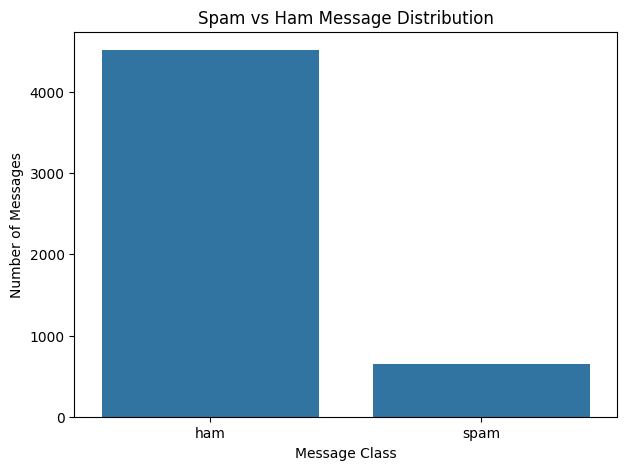

In [25]:
# Create a bar chart for spam vs ham messages

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="label")

plt.title("Spam vs Ham Message Distribution")
plt.xlabel("Message Class")
plt.ylabel("Number of Messages")

plt.show()

## Step 10: Text Preprocessing

In [26]:
# Create a separate column for the cleaned message
# This keeps the original message unchanged for reference

df["cleaned_message"] = df["message"].copy()

# Display the original and cleaned messages
display(df[["message", "cleaned_message"]].head())

,message,cleaned_message
0,"Go until jurong point, crazy.. Available only ...","Go until jurong point, crazy.. Available only ..."
1,Ok lar... Joking wif u oni...,Ok lar... Joking wif u oni...
2,Free entry in 2 a wkly comp to win FA Cup fina...,Free entry in 2 a wkly comp to win FA Cup fina...
3,U dun say so early hor... U c already then say...,U dun say so early hor... U c already then say...
4,"Nah I don't think he goes to usf, he lives aro...","Nah I don't think he goes to usf, he lives aro..."


## Step 11: Convert Text to Lowercase

In [27]:
# Convert all messages to lowercase

df["cleaned_message"] = df["cleaned_message"].str.lower()

# Display original and lowercase messages for comparison
display(df[["message", "cleaned_message"]].head())

,message,cleaned_message
0,"Go until jurong point, crazy.. Available only ...","go until jurong point, crazy.. available only ..."
1,Ok lar... Joking wif u oni...,ok lar... joking wif u oni...
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...
3,U dun say so early hor... U c already then say...,u dun say so early hor... u c already then say...
4,"Nah I don't think he goes to usf, he lives aro...","nah i don't think he goes to usf, he lives aro..."


## Step 12: Remove Punctuation and Unwanted Characters

In [28]:
# Remove punctuation and unwanted special characters
# Keep letters, numbers, and whitespace

df["cleaned_message"] = df["cleaned_message"].apply(
    lambda text: re.sub(r"[^a-zA-Z0-9\s]", "", text)
)

# Remove extra spaces
df["cleaned_message"] = df["cleaned_message"].apply(
    lambda text: re.sub(r"\s+", " ", text).strip()
)

# Display original and cleaned messages for comparison
display(df[["message", "cleaned_message"]].head())

,message,cleaned_message
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...


## Step 13: Remove Stopwords

In [29]:
# Download the NLTK stopword dataset

nltk.download("stopwords")

from nltk.corpus import stopwords

# Create the English stopword set
stop_words = set(stopwords.words("english"))

# Remove stopwords from each message
df["cleaned_message"] = df["cleaned_message"].apply(
    lambda text: " ".join(
        word for word in text.split()
        if word not in stop_words
    )
)

# Display original and cleaned messages
display(df[["message", "cleaned_message"]].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,message,cleaned_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


## Step 14: Optional Stemming/Lemmatization

In [30]:
# Stemming and lemmatization are not applied in this project.
# The cleaned text will be used directly for TF-IDF feature extraction.

print("Stemming/Lemmatization: Not applied")
print("Reason: The cleaned text is sufficient for TF-IDF-based spam classification.")

Stemming/Lemmatization: Not applied
Reason: The cleaned text is sufficient for TF-IDF-based spam classification.


## Step 15: Understand TF-IDF

### TF — Term Frequency

Term Frequency measures how frequently a word appears in a particular document.

### IDF — Inverse Document Frequency

Inverse Document Frequency measures how rare or common a word is across the entire collection of documents.

### TF-IDF

TF-IDF (Term Frequency-Inverse Document Frequency) converts text into numerical values by giving higher importance to words that are useful for distinguishing documents, while reducing the importance of words that appear very frequently across many documents.

In this project, TF-IDF will convert the cleaned SMS messages into numerical features that can be used by the machine learning classifiers.

## Step 16: Convert Text into TF-IDF Features

In [31]:
# Create the TF-IDF Vectorizer

tfidf_vectorizer = TfidfVectorizer()

print("TF-IDF Vectorizer created successfully.")
print("Default parameters will be used for feature extraction.")

TF-IDF Vectorizer created successfully.
Default parameters will be used for feature extraction.


## Step 17: Prepare Features and Target

In [32]:
# Separate the cleaned text and target labels

X_text = df["cleaned_message"]

# Encode ham as 0 and spam as 1
y = df["label"].map({
    "ham": 0,
    "spam": 1
})

# Display the shape of the text features and target
print("Text feature shape:", X_text.shape)
print("Target shape:", y.shape)

# Display the first five target values
print("\nFirst five target values:")
print(y.head())

# Check that no labels failed to convert
print("\nMissing encoded labels:", y.isnull().sum())

Text feature shape: (5169,)
Target shape: (5169,)

First five target values:
0    0
1    0
2    1
3    0
4    0
Name: label, dtype: int64

Missing encoded labels: 0


## Step 18: Split the Dataset into Training and Testing Sets

In [33]:
# Split the text data and target into training and testing sets

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Fit TF-IDF only on the training data
X_train = tfidf_vectorizer.fit_transform(X_train_text)

# Transform the test data using the vocabulary learned from training data
X_test = tfidf_vectorizer.transform(X_test_text)

# Display the resulting shapes
print("Training text shape:", X_train_text.shape)
print("Testing text shape:", X_test_text.shape)

print("\nTraining TF-IDF shape:", X_train.shape)
print("Testing TF-IDF shape:", X_test.shape)

print("\nTraining target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training text shape: (4135,)
Testing text shape: (1034,)

Training TF-IDF shape: (4135, 8228)
Testing TF-IDF shape: (1034, 8228)

Training target shape: (4135,)
Testing target shape: (1034,)


## Step 19: Train Multinomial Naive Bayes Model

In [34]:
# Create and train the Multinomial Naive Bayes classifier

nb_model = MultinomialNB()

# Train the model using the training TF-IDF features
nb_model.fit(X_train, y_train)

print("Multinomial Naive Bayes model trained successfully.")

Multinomial Naive Bayes model trained successfully.


## Step 20: Train Logistic Regression Model

In [35]:
# Create and train the Logistic Regression classifier

lr_model = LogisticRegression(max_iter=1000)

# Train the model using the training TF-IDF features
lr_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


## Step 21: Make Predictions

In [36]:
# Generate predictions using both trained models

y_pred_nb = nb_model.predict(X_test)
y_pred_lr = lr_model.predict(X_test)

# Display a few predictions
print("First 10 Naive Bayes predictions:")
print(y_pred_nb[:10])

print("\nFirst 10 Logistic Regression predictions:")
print(y_pred_lr[:10])

# Display the corresponding actual labels
print("\nFirst 10 actual labels:")
print(y_test.values[:10])

First 10 Naive Bayes predictions:
[0 0 0 0 0 0 0 0 0 0]

First 10 Logistic Regression predictions:
[0 0 0 0 0 0 0 0 0 0]

First 10 actual labels:
[0 0 0 0 0 0 0 0 0 0]


## Step 22: Evaluate Naive Bayes Model

In [37]:
# Calculate evaluation metrics for the Naive Bayes model

nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_precision = precision_score(y_test, y_pred_nb)
nb_recall = recall_score(y_test, y_pred_nb)
nb_f1 = f1_score(y_test, y_pred_nb)

print("Naive Bayes Evaluation")
print("----------------------")
print("Accuracy :", round(nb_accuracy, 4))
print("Precision:", round(nb_precision, 4))
print("Recall   :", round(nb_recall, 4))
print("F1-Score :", round(nb_f1, 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_nb,
    target_names=["Ham", "Spam"]
))

Naive Bayes Evaluation
----------------------
Accuracy : 0.9623
Precision: 1.0
Recall   : 0.7023
F1-Score : 0.8251

Classification Report:
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       903
        Spam       1.00      0.70      0.83       131

    accuracy                           0.96      1034
   macro avg       0.98      0.85      0.90      1034
weighted avg       0.96      0.96      0.96      1034



## Step 23: Evaluate Logistic Regression Model

In [38]:
# Calculate evaluation metrics for the Logistic Regression model

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

print("Logistic Regression Evaluation")
print("------------------------------")
print("Accuracy :", round(lr_accuracy, 4))
print("Precision:", round(lr_precision, 4))
print("Recall   :", round(lr_recall, 4))
print("F1-Score :", round(lr_f1, 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=["Ham", "Spam"]
))

Logistic Regression Evaluation
------------------------------
Accuracy : 0.9526
Precision: 0.9457
Recall   : 0.6641
F1-Score : 0.7803

Classification Report:
              precision    recall  f1-score   support

         Ham       0.95      0.99      0.97       903
        Spam       0.95      0.66      0.78       131

    accuracy                           0.95      1034
   macro avg       0.95      0.83      0.88      1034
weighted avg       0.95      0.95      0.95      1034



## Step 24: Generate Confusion Matrices

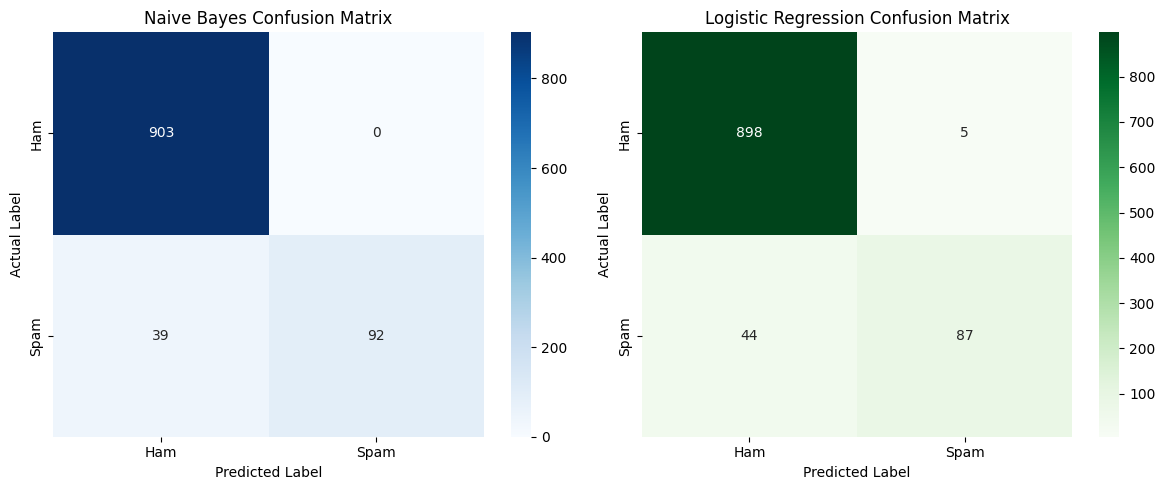

Naive Bayes Confusion Matrix:
[[903   0]
 [ 39  92]]

Logistic Regression Confusion Matrix:
[[898   5]
 [ 44  87]]


In [39]:
# Generate confusion matrices for both models

nb_cm = confusion_matrix(y_test, y_pred_nb)
lr_cm = confusion_matrix(y_test, y_pred_lr)

# Create confusion matrix visualizations
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Naive Bayes confusion matrix
sns.heatmap(
    nb_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"],
    ax=axes[0]
)

axes[0].set_title("Naive Bayes Confusion Matrix")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("Actual Label")

# Logistic Regression confusion matrix
sns.heatmap(
    lr_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"],
    ax=axes[1]
)

axes[1].set_title("Logistic Regression Confusion Matrix")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("Actual Label")

plt.tight_layout()
plt.show()

# Display the numerical confusion matrices
print("Naive Bayes Confusion Matrix:")
print(nb_cm)

print("\nLogistic Regression Confusion Matrix:")
print(lr_cm)

## Step 25: Compare Classification Models

In [40]:
# Create a comparison table for both classification models

model_comparison = pd.DataFrame({
    "Model": [
        "Multinomial Naive Bayes",
        "Logistic Regression"
    ],
    "Accuracy": [
        nb_accuracy,
        lr_accuracy
    ],
    "Precision": [
        nb_precision,
        lr_precision
    ],
    "Recall": [
        nb_recall,
        lr_recall
    ],
    "F1-Score": [
        nb_f1,
        lr_f1
    ]
})

# Round the metric values for better readability
model_comparison[
    ["Accuracy", "Precision", "Recall", "F1-Score"]
] = model_comparison[
    ["Accuracy", "Precision", "Recall", "F1-Score"]
].round(4)

# Display the comparison table
display(model_comparison)

,Model,Accuracy,Precision,Recall,F1-Score
0,Multinomial Naive Bayes,0.9623,1.0000,0.7023,0.8251
1,Logistic Regression,0.9526,0.9457,0.6641,0.7803


## Step 26: Explain the Importance of Recall for Spam Detection

Recall is particularly important in spam detection because it measures how many of the actual spam messages are correctly identified by the model.

A **False Negative** occurs when an actual spam message is incorrectly classified as a legitimate (ham) message. This means the spam message passes through the filter and reaches the user.

For spam detection, a higher recall helps reduce the number of spam messages that are missed by the classifier.

However, recall should not be considered alone. A model that aggressively classifies messages as spam may produce more **False Positives**, where legitimate messages are incorrectly classified as spam. This can cause important or genuine messages to be blocked.

Therefore, an effective spam detection system should aim for a good balance between **precision and recall**, while also considering the F1-score and confusion matrix.

In this project, Multinomial Naive Bayes achieved a spam recall of **0.7023**, meaning it correctly identified approximately **70.23% of the actual spam messages** in the test set. Its precision was **1.0000**, meaning none of the messages predicted as spam were actually legitimate messages in this test set.

## Step 27: WordCloud Visualization for Spam Messages

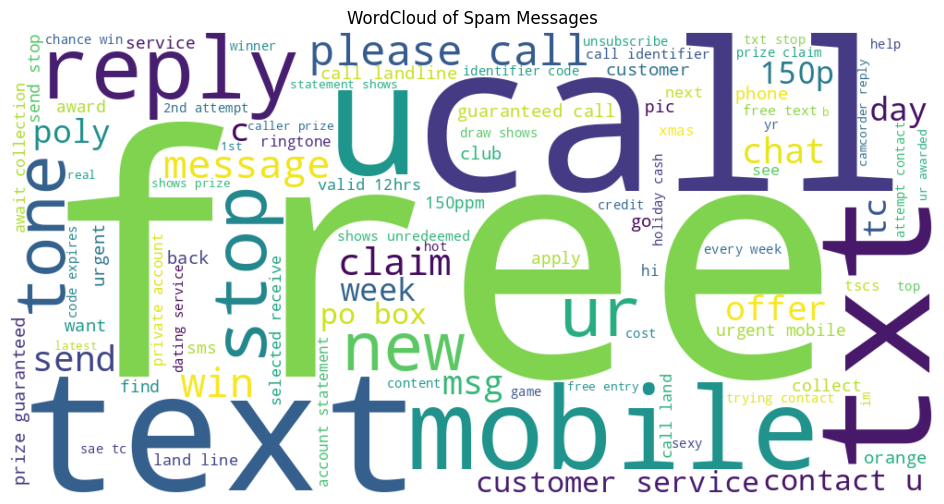

In [41]:
# Combine all cleaned spam messages into one text string

spam_text = " ".join(
    df.loc[df["label"] == "spam", "cleaned_message"]
)

# Generate the spam WordCloud
spam_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=100
).generate(spam_text)

# Display the WordCloud
plt.figure(figsize=(12, 6))
plt.imshow(spam_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud of Spam Messages")
plt.show()

## Step 28: WordCloud Visualization for Ham Messages

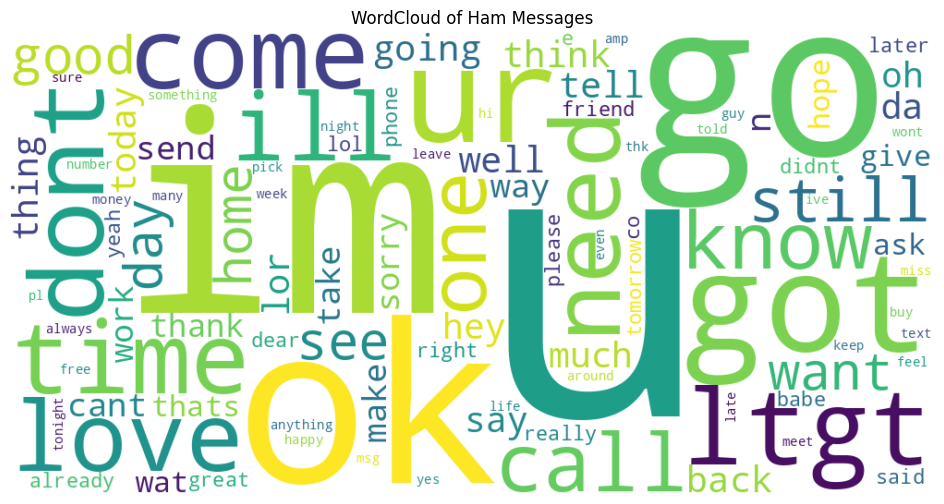

In [42]:
# Combine all cleaned ham messages into one text string

ham_text = " ".join(
    df.loc[df["label"] == "ham", "cleaned_message"]
)

# Generate the ham WordCloud
ham_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=100
).generate(ham_text)

# Display the WordCloud
plt.figure(figsize=(12, 6))
plt.imshow(ham_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud of Ham Messages")
plt.show()

## Step 29: Select the Best-Performing Model

In [43]:
# Select the best-performing model based on F1-score

best_model_row = model_comparison.loc[
    model_comparison["F1-Score"].idxmax()
]

best_model_name = best_model_row["Model"]
best_f1_score = best_model_row["F1-Score"]

print("Best-Performing Model:", best_model_name)
print("F1-Score:", best_f1_score)

# Display the complete performance of the selected model
print("\nBest Model Performance:")
display(
    model_comparison[
        model_comparison["Model"] == best_model_name
    ]
)

Best-Performing Model: Multinomial Naive Bayes
F1-Score: 0.8251

Best Model Performance:


,Model,Accuracy,Precision,Recall,F1-Score
0,Multinomial Naive Bayes,0.9623,1.0,0.7023,0.8251


## Step 30: Final Model Interpretation

The completed email spam detection pipeline begins with the SMS Spam Collection dataset. Duplicate messages were identified and removed, after which the dataset contained 5,169 messages.

The text data was prepared through lowercase conversion, punctuation and unwanted-character removal, and English stopword removal. Stemming and lemmatization were not applied because the cleaned text was considered sufficient for the TF-IDF-based classification approach.

TF-IDF was used to convert the cleaned SMS messages into numerical features. The dataset was divided into training and testing sets using an 80:20 split with stratification. The TF-IDF vectorizer was fitted only on the training data to avoid data leakage.

Two classification models were trained: Multinomial Naive Bayes and Logistic Regression.

Multinomial Naive Bayes achieved an accuracy of 96.23%, precision of 100.00%, recall of 70.23%, and F1-score of 82.51%. Logistic Regression achieved an accuracy of 95.26%, precision of 94.57%, recall of 66.41%, and F1-score of 78.03%.

Based on the evaluation results, Multinomial Naive Bayes performed better than Logistic Regression for this dataset. Its confusion matrix contained 903 correctly classified ham messages, 92 correctly classified spam messages, 39 spam messages classified as ham, and no ham messages classified as spam.

The main remaining error is the false-negative classification of some spam messages as legitimate messages. Therefore, although the model performs well overall, improving spam recall could be an important area for future improvement.

The main limitation of the project is that the model is trained on a specific SMS dataset and may not perform identically on newer or substantially different types of spam messages.

## Step 31: Conclusion

This project successfully developed an NLP-based machine learning system for detecting spam messages. The SMS Spam Collection dataset was cleaned and prepared through text preprocessing, including lowercase conversion, punctuation removal, and stopword removal.

TF-IDF was used to transform the cleaned messages into numerical features, and the dataset was divided into training and testing sets using a stratified 80:20 split.

Two classification algorithms, Multinomial Naive Bayes and Logistic Regression, were trained and evaluated using accuracy, precision, recall, F1-score, and confusion matrices.

Multinomial Naive Bayes achieved the best overall performance, with an accuracy of 96.23%, precision of 100.00%, recall of 70.23%, and F1-score of 82.51%.

The results demonstrate that traditional NLP techniques combined with machine learning can effectively classify spam and legitimate messages. However, some spam messages were still classified as ham, showing that further improvements could focus on increasing spam recall while maintaining high precision.